# VENTO V2 — pipeline reproducible de disponibilidad, riesgo y abordaje

Este notebook reconstruye las fases 2 y 3 del método: usa la disponibilidad espacial ya incluida en el dataset municipal, normaliza DIVIPOLA, calcula el índice de riesgo, asigna la modalidad de abordaje y exporta las tablas completas, QGIS y priorizada. La superposición SIG de restricciones y viento (fase 1) ocurrió antes del dataset.

**Entradas requeridas:** dataset municipal y DIVIPOLA. Si el CSV original de DIVIPOLA no está en la carpeta, se usa como respaldo trazable el diccionario incluido en el CSV final de referencia; el notebook lo informa al ejecutar.

In [3]:
# CELDA 1 — Configuración del entorno y parámetros metodológicos.
# Importa las librerías para leer/manipular tablas y define dónde están las entradas y salidas.
# Los pesos y el umbral quedan centralizados aquí para que puedas modificarlos de forma auditable.
from pathlib import Path
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:  # Permite ejecutar también como script con Python mínimo.
    display = print

# Ajuste esta ruta si los archivos están en otra carpeta.
DATA_DIR = Path(r'C:\Users\felip\Downloads\VARIABLES EXCLUYENTES - 951\ELECCION ZONAS VISITAS')
BASE_FILE = DATA_DIR / '[dataset Alejo vf] df_completo_pipe_colV2.csv'
DIVIPOLA_FILE = DATA_DIR / 'DIVIPOLA_Municipios (2).csv'
REFERENCE_FILE = DATA_DIR / 'VENTO_V2_csv_completo_risk_densidad_divipola.csv'
OUTPUT_DIR = DATA_DIR / 'salidas_notebook_vento'
OUTPUT_DIR.mkdir(exist_ok=True)

assert BASE_FILE.exists(), f'No se encontró: {BASE_FILE}'

PESOS = {
    'indice_pena_media_0_100': 0.35,
    'cantidad_grupos_armados_en_el_mpio': 0.30,
    'coca_log': 0.20,
    'cercania_coca': 0.15,
}
UMBRAL_DENSIDAD = 15.0


In [4]:
# CELDA 2 — Funciones auxiliares y carga de la tabla oficial DIVIPOLA.
# La función de lectura prueba codificaciones habituales para evitar problemas con tildes.
# La función de código DIVIPOLA convierte cada identificador municipal a cinco dígitos y conserva ceros iniciales.
# Si está disponible, se usa el CSV DIVIPOLA original; si no, se extrae su diccionario del CSV V2 de referencia.
def read_csv_robusto(path, **kwargs):
    """Lee UTF-8 y usa latin-1 como respaldo para archivos administrativos."""
    for encoding in ('utf-8-sig', 'utf-8', 'latin1'):
        try:
            return pd.read_csv(path, encoding=encoding, **kwargs)
        except UnicodeDecodeError:
            continue
    raise UnicodeError(f'No se pudo leer {path}')

def codigo_divipola(series):
    """Convierte códigos a texto de cinco dígitos y conserva ceros iniciales."""
    valor = pd.to_numeric(series.astype(str).str.replace('.0', '', regex=False), errors='coerce')
    return valor.astype('Int64').astype('string').str.zfill(5)

DIVIPOLA_COLUMNS = [
    'codigo_departamento_divipola', 'nombre_departamento',
    'codigo_municipio_divipola', 'nombre_municipio',
    'tipo_entidad_divipola', 'longitud_divipola', 'latitud_divipola', 'nota_divipola',
]

def cargar_divipola():
    """Carga DIVIPOLA original o, en su ausencia, el diccionario del CSV de referencia."""
    if DIVIPOLA_FILE.exists():
        div = read_csv_robusto(DIVIPOLA_FILE, dtype=str)
        # Admite tanto los encabezados estandarizados como el formato oficial descargado de DIVIPOLA.
        lower = {str(c).strip().lower(): c for c in div.columns}
        if 'codigo_municipio_divipola' in lower:
            rename = {lower[c]: c for c in DIVIPOLA_COLUMNS if c in lower}
        elif len(div.columns) >= 8:
            raw = list(div.columns)
            rename = dict(zip(raw[:8], DIVIPOLA_COLUMNS))
        else:
            rename = {}
        div = div.rename(columns=rename)
        if 'codigo_municipio_divipola' not in div.columns:
            raise KeyError('DIVIPOLA debe incluir codigo_municipio_divipola.')
        fuente = DIVIPOLA_FILE.name
    else:
        assert REFERENCE_FILE.exists(), (
            'Falta DIVIPOLA y tampoco existe el CSV final de referencia para construir el respaldo.'
        )
        ref = read_csv_robusto(REFERENCE_FILE, dtype={'COD_MPIO_DIVIPOLA': 'string'})
        div = ref.loc[ref['check_cruce_divipola'].eq('OK'), ['COD_MPIO_DIVIPOLA', *DIVIPOLA_COLUMNS]].copy()
        div = div.rename(columns={'COD_MPIO_DIVIPOLA': '_codigo_union'})
        fuente = f'{REFERENCE_FILE.name} (respaldo de DIVIPOLA)'

    for c in DIVIPOLA_COLUMNS:
        if c not in div.columns:
            div[c] = pd.NA
    if '_codigo_union' not in div.columns:
        div['_codigo_union'] = codigo_divipola(div['codigo_municipio_divipola'])
    div['_codigo_union'] = codigo_divipola(div['_codigo_union'])
    div['codigo_municipio_divipola'] = pd.to_numeric(div['codigo_municipio_divipola'], errors='coerce').astype('Int64')
    div = div[['_codigo_union', *DIVIPOLA_COLUMNS]].drop_duplicates('_codigo_union')
    return div, fuente

divipola, fuente_divipola = cargar_divipola()
print(f'Fuente DIVIPOLA: {fuente_divipola}; registros de referencia: {len(divipola):,}')


Fuente DIVIPOLA: DIVIPOLA_Municipios (2).csv; registros de referencia: 1,123


In [5]:
# CELDA 3 — Integración de las tres fuentes de información.
# 1. Carga el dataset municipal original y comprueba que tenga 1.122 municipios únicos.
# 2. Genera las llaves DIVIPOLA de texto y numérica, y une los nombres/coordenadas oficiales.
# 3. Toma la densidad de píxeles disponibles directamente del dataset base.
# No se requiere un archivo adicional de densidades y ningún municipio del dataset base se elimina.
base = read_csv_robusto(BASE_FILE)
assert len(base) == 1122, f'Se esperaban 1.122 municipios; se encontraron {len(base):,}.'
assert base['id_unificado'].is_unique, 'La base tiene id_unificado duplicados.'

codigos = pd.DataFrame({
    'COD_MPIO_DIVIPOLA': codigo_divipola(base['id_unificado']),
    'COD_MPIO_NUM': pd.to_numeric(base['id_unificado'], errors='coerce').astype('Int64'),
})
assert codigos['COD_MPIO_DIVIPOLA'].notna().all(), 'Hay códigos municipales inválidos.'

# 2. Unión con DIVIPOLA. Se preservan todos los municipios de la base.
trabajo = pd.concat([base[['id_unificado']].copy(), codigos], axis=1)
trabajo = trabajo.merge(divipola, how='left', left_on='COD_MPIO_DIVIPOLA', right_on='_codigo_union', validate='one_to_one')
trabajo = trabajo.drop(columns='_codigo_union')
for c in ['nombre_departamento', 'nombre_municipio']:
    trabajo[c] = trabajo[c].fillna('SIN_COINCIDENCIA_DIVIPOLA')

# 3. La densidad ya está incluida en la base. Se renombra para conservar un nombre explícito en las salidas.
trabajo['densidad_pixeles_disponibles_pct_exacta'] = pd.to_numeric(base['densidad_pixeles_dentro_mpio'], errors='coerce')

print(f'Municipios base: {len(base):,}')
print(f'Coincidencias DIVIPOLA: {trabajo['nombre_departamento'].ne('SIN_COINCIDENCIA_DIVIPOLA').sum():,}')
print(f'Coincidencias densidad: {trabajo['densidad_pixeles_disponibles_pct_exacta'].notna().sum():,}')


Municipios base: 1,122
Coincidencias DIVIPOLA: 1,121
Coincidencias densidad: 1,122


In [6]:
# CELDA 4 — Construcción reproducible del índice de riesgo.
# Primero transforma la densidad de coca con log(1+x) y la distancia en una medida de cercanía 1/(1+distancia).
# Después imputa únicamente valores faltantes con la mediana nacional y deja una marca por variable imputada.
# Finalmente estandariza con Z-score poblacional (ddof=0), combina los cuatro componentes con sus pesos,
# normaliza el resultado entre 0 y 1 y clasifica Bajo/Medio/Alto usando P50 y P75.
score = base[[
    'indice_pena_media_0_100', 'cantidad_grupos_armados_en_el_mpio',
    'densidad_cultivos_coca_ha_km2', 'dist_min_coca_km',
]].apply(pd.to_numeric, errors='coerce').copy()
score['coca_log'] = np.log1p(score['densidad_cultivos_coca_ha_km2'])
score['dist_min_coca_km_risk'] = score['dist_min_coca_km']
score['cercania_coca'] = 1 / (1 + score['dist_min_coca_km_risk'])

origenes = {
    'indice_pena_media_0_100': 'indice_pena_media_0_100',
    'cantidad_grupos_armados_en_el_mpio': 'cantidad_grupos_armados_en_el_mpio',
    'coca_log': 'coca_log',
    'cercania_coca': 'cercania_coca',
}
imputados, checks_imputacion = {}, {}
for nombre, origen in origenes.items():
    faltante = score[origen].isna()
    imputados[f'{nombre}_imputado_para_risk'] = score[origen].fillna(score[origen].median())
    checks_imputacion[f'check_imputacion_{nombre}'] = np.where(faltante, 'IMPUTADO_MEDIANA', 'SIN_IMPUTACION')

imp = pd.DataFrame(imputados)
z = pd.DataFrame({
    'z_indice_pena_media': (imp['indice_pena_media_0_100_imputado_para_risk'] - imp['indice_pena_media_0_100_imputado_para_risk'].mean()) / imp['indice_pena_media_0_100_imputado_para_risk'].std(ddof=0),
    'z_cantidad_grupos_armados': (imp['cantidad_grupos_armados_en_el_mpio_imputado_para_risk'] - imp['cantidad_grupos_armados_en_el_mpio_imputado_para_risk'].mean()) / imp['cantidad_grupos_armados_en_el_mpio_imputado_para_risk'].std(ddof=0),
    'z_coca_log': (imp['coca_log_imputado_para_risk'] - imp['coca_log_imputado_para_risk'].mean()) / imp['coca_log_imputado_para_risk'].std(ddof=0),
    'z_cercania_coca': (imp['cercania_coca_imputado_para_risk'] - imp['cercania_coca_imputado_para_risk'].mean()) / imp['cercania_coca_imputado_para_risk'].std(ddof=0),
})
risk_raw = 0.35*z['z_indice_pena_media'] + 0.30*z['z_cantidad_grupos_armados'] + 0.20*z['z_coca_log'] + 0.15*z['z_cercania_coca']
risk_01 = (risk_raw - risk_raw.min()) / (risk_raw.max() - risk_raw.min())
p50, p75 = risk_01.quantile([0.50, 0.75])
riesgo = pd.Series(np.select([risk_01.le(p50), risk_01.le(p75)], ['Bajo', 'Medio'], default='Alto'), name='riesgo_categoria')
abordaje = riesgo.map({'Bajo': 'Presencial', 'Medio': 'Presencial con precaución', 'Alto': 'Remota'}).rename('tipo_abordaje_zona')

print(f'P50: {p50:.8f} | P75: {p75:.8f}')
display(pd.DataFrame({'riesgo': riesgo.value_counts(), 'abordaje': abordaje.value_counts()}))


P50: 0.28080170 | P75: 0.39816811


,riesgo,abordaje
Alto,281.0,NaN
Bajo,561.0,NaN
Medio,280.0,NaN
Presencial,NaN,561.0
Presencial con precaución,NaN,280.0
Remota,NaN,281.0


In [7]:
# CELDA 5 — Ensamble del producto final, controles y archivos de salida.
# Reúne columnas originales, nombres DIVIPOLA, cálculos de riesgo y densidad en una sola tabla municipal.
# Crea las columnas de chequeo para cruces, formato, inputs e imputaciones; luego redacta la observación de cada fila.
# Exporta: (1) base completa, (2) tabla compacta para QGIS, (3) municipios con densidad >15% y (4) reporte TXT.
risk_columns = pd.concat([
    imp,
    score[['coca_log', 'dist_min_coca_km_risk', 'cercania_coca']],
    z,
    risk_raw.rename('risk_raw_seguridad'), risk_01.rename('risk_score_01_calculado'), riesgo, abordaje,
], axis=1)
resultado = pd.concat([
    trabajo[['id_unificado', 'COD_MPIO_DIVIPOLA', 'COD_MPIO_NUM', *DIVIPOLA_COLUMNS]],
    base.drop(columns='id_unificado'), risk_columns,
    trabajo[['densidad_pixeles_disponibles_pct_exacta']],
], axis=1)
# Se conserva la precisión publicada en el producto V2 (ocho decimales) para facilitar auditoría y comparación.
columnas_redondeadas = [*imp.columns, 'coca_log', 'cercania_coca', *z.columns, 'risk_raw_seguridad', 'risk_score_01_calculado', 'densidad_pixeles_disponibles_pct_exacta']
resultado[columnas_redondeadas] = resultado[columnas_redondeadas].round(8)
resultado['universo_111_densidad_gt15'] = np.where(resultado['densidad_pixeles_disponibles_pct_exacta'].gt(UMBRAL_DENSIDAD), 'SI', 'NO')

for col, values in checks_imputacion.items():
    resultado[col] = values
resultado['check_cruce_divipola'] = np.where(resultado['nombre_departamento'].eq('SIN_COINCIDENCIA_DIVIPOLA'), 'SIN_COINCIDENCIA_DIVIPOLA', 'OK')
resultado['check_cruce_densidad'] = np.where(resultado['densidad_pixeles_disponibles_pct_exacta'].isna(), 'SIN_COINCIDENCIA_DENSIDAD', 'OK')
resultado['check_codigo_divipola_5_digitos'] = np.where(resultado['COD_MPIO_DIVIPOLA'].str.fullmatch(r'\d{5}', na=False), 'OK', 'ERROR_FORMATO')
resultado['check_inputs_risk_score'] = np.where(imp.notna().all(axis=1), 'OK', 'ERROR_INPUTS')
resultado['check_imputacion_risk_score'] = np.where((pd.DataFrame(checks_imputacion) == 'IMPUTADO_MEDIANA').any(axis=1), 'CON_IMPUTACION', 'SIN_IMPUTACION')

def observacion(row):
    notas = []
    if row['check_cruce_divipola'] != 'OK':
        notas.append('No tiene coincidencia en DIVIPOLA suministrado')
    if row['check_cruce_densidad'] != 'OK':
        notas.append('No tiene coincidencia en archivo de densidad suministrado')
    if row['check_imputacion_risk_score'] == 'CON_IMPUTACION':
        notas.append('Risk score calculado con imputación de mediana en al menos un input')
    return ' | '.join(notas) if notas else 'OK'

resultado['observacion_validacion'] = resultado.apply(observacion, axis=1)

qgis_cols = ['COD_MPIO_DIVIPOLA', 'COD_MPIO_NUM', 'id_unificado', 'codigo_departamento_divipola', 'nombre_departamento', 'nombre_municipio', 'tipo_entidad_divipola', 'longitud_divipola', 'latitud_divipola', 'densidad_pixeles_disponibles_pct_exacta', 'risk_raw_seguridad', 'risk_score_01_calculado', 'riesgo_categoria', 'tipo_abordaje_zona', 'universo_111_densidad_gt15', 'check_cruce_divipola', 'check_cruce_densidad', 'check_codigo_divipola_5_digitos', 'check_inputs_risk_score', 'check_imputacion_risk_score', 'observacion_validacion']
priorizados = resultado.loc[resultado['universo_111_densidad_gt15'].eq('SI')].copy()

archivo_completo = OUTPUT_DIR / 'VENTO_reproducido_csv_completo_risk_densidad_divipola.csv'
archivo_qgis = OUTPUT_DIR / 'VENTO_reproducido_qgis_abordaje_municipal.csv'
archivo_priorizados = OUTPUT_DIR / 'VENTO_reproducido_municipios_densidad_gt15.csv'
resultado.to_csv(archivo_completo, index=False, encoding='utf-8-sig')
resultado[qgis_cols].to_csv(archivo_qgis, index=False, encoding='utf-8-sig')
priorizados.to_csv(archivo_priorizados, index=False, encoding='utf-8-sig')

resumen = [
    'VALIDACIÓN DE CRUCES Y CONTEOS — VENTO REPRODUCIDO', '',
'1. Archivos fuente', f'- Base principal (incluye densidad): {BASE_FILE.name}', f'- DIVIPOLA: {fuente_divipola}', '',
'2. Conteo de registros', f'- Registros en base principal: {len(base):,}', f'- Registros en CSV completo final: {len(resultado):,}', f'- Registros en CSV QGIS final: {len(resultado):,}', f'- Registros con densidad > 15%: {len(priorizados):,}', '',
'3. Validación de cruces', f'- Coincidencias con DIVIPOLA: {resultado.check_cruce_divipola.eq(chr(79)+chr(75)).sum():,}', f'- Sin coincidencia con DIVIPOLA: {resultado.check_cruce_divipola.ne(chr(79)+chr(75)).sum():,}', f'- Coincidencias con densidad: {resultado.check_cruce_densidad.eq(chr(79)+chr(75)).sum():,}', f'- Códigos con formato DIVIPOLA de 5 dígitos: {resultado.check_codigo_divipola_5_digitos.eq(chr(79)+chr(75)).sum():,}', '',
'4. Risk score', '- Pesos: penal=0.35; grupos armados=0.30; coca log=0.20; cercanía coca=0.15.', f'- Registros con imputación por mediana: {resultado.check_imputacion_risk_score.eq('CON_IMPUTACION').sum():,}', f'- Percentil 50: {p50:.8f}', f'- Percentil 75: {p75:.8f}', '',
'5. Conteos por categoría de riesgo, total nacional', *[f'- {k}: {v:,}' for k, v in resultado.riesgo_categoria.value_counts().reindex(['Bajo','Medio','Alto']).items()], '',
'6. Conteos por categoría de riesgo, municipios con densidad > 15%', *[f'- {k}: {v:,}' for k, v in priorizados.riesgo_categoria.value_counts().reindex(['Bajo','Medio','Alto']).fillna(0).astype(int).items()],
]
archivo_validacion = OUTPUT_DIR / 'VENTO_reproducido_validacion_cruces_conteos.txt'
archivo_validacion.write_text('\n'.join(resumen), encoding='utf-8')

print('Archivos creados:')
for archivo in [archivo_completo, archivo_qgis, archivo_priorizados, archivo_validacion]:
    print(' -', archivo)
display(resultado[['id_unificado', 'nombre_departamento', 'nombre_municipio', 'densidad_pixeles_disponibles_pct_exacta', 'risk_score_01_calculado', 'riesgo_categoria', 'tipo_abordaje_zona']].head())


Archivos creados:
 - C:\Users\felip\Downloads\VARIABLES EXCLUYENTES - 951\ELECCION ZONAS VISITAS\salidas_notebook_vento\VENTO_reproducido_csv_completo_risk_densidad_divipola.csv
 - C:\Users\felip\Downloads\VARIABLES EXCLUYENTES - 951\ELECCION ZONAS VISITAS\salidas_notebook_vento\VENTO_reproducido_qgis_abordaje_municipal.csv
 - C:\Users\felip\Downloads\VARIABLES EXCLUYENTES - 951\ELECCION ZONAS VISITAS\salidas_notebook_vento\VENTO_reproducido_municipios_densidad_gt15.csv
 - C:\Users\felip\Downloads\VARIABLES EXCLUYENTES - 951\ELECCION ZONAS VISITAS\salidas_notebook_vento\VENTO_reproducido_validacion_cruces_conteos.txt


,id_unificado,nombre_departamento,nombre_municipio,densidad_pixeles_disponibles_pct_exacta,risk_score_01_calculado,riesgo_categoria,tipo_abordaje_zona
0,5001,ANTIOQUIA,MEDELLÍN,0.95,0.457165,Alto,Remota
1,5002,ANTIOQUIA,ABEJORRAL,1.03,0.389069,Medio,Presencial con precaución
2,5004,ANTIOQUIA,ABRIAQUÍ,2.35,0.000818,Bajo,Presencial
3,5021,ANTIOQUIA,ALEJANDRÍA,0.00,0.284738,Medio,Presencial con precaución
4,5030,ANTIOQUIA,AMAGÁ,0.00,0.310215,Medio,Presencial con precaución


In [8]:
# CELDA 6 — Reconciliación opcional contra el producto V2 entregado.
# Esta celda no es necesaria para producir los resultados: es una prueba de auditoría.
# Compara el score de riesgo, las categorías y los controles; si algo difiere, detiene la ejecución con un mensaje claro.
if REFERENCE_FILE.exists():
    referencia = read_csv_robusto(REFERENCE_FILE, dtype={'COD_MPIO_DIVIPOLA': 'string'})
    # La densidad no se compara: el V2 usó una columna SIG con más decimales que la incluida en la base.
    columnas_numericas = ['risk_raw_seguridad', 'risk_score_01_calculado']
    columnas_texto = ['riesgo_categoria', 'tipo_abordaje_zona', 'universo_111_densidad_gt15', 'check_cruce_divipola', 'check_cruce_densidad', 'check_imputacion_risk_score']
    validacion_numerica = all(np.allclose(resultado[c].astype(float), referencia[c].astype(float), equal_nan=True, rtol=0, atol=0) for c in columnas_numericas)
    validacion_texto = all(resultado[c].fillna('').astype(str).equals(referencia[c].fillna('').astype(str)) for c in columnas_texto)
    print('Coincidencia numérica con V2:', validacion_numerica)
    print('Coincidencia categórica y de controles con V2:', validacion_texto)
    assert validacion_numerica and validacion_texto, 'Revise las entradas, pesos o fuente DIVIPOLA: la reconciliación no coincide.'
else:
    print('No hay CSV V2 de referencia; se omitió la reconciliación.')


Coincidencia numérica con V2: True
Coincidencia categórica y de controles con V2: True


## Análisis de sensibilidad de los pesos

Las celdas siguientes prueban si la clasificación y la modalidad de abordaje se mantienen al modificar los pesos. En cada prueba se vuelve a calcular el score, P50 y P75; por tanto, se conserva la regla de clasificación relativa definida en la metodología.

In [9]:
# CELDA 7 — Escenarios determinísticos de pesos.
# Evalúa todos los escenarios definidos abajo; puedes agregar nuevas filas siempre que sus cuatro pesos sumen 1.
# Para cada escenario recalcula score, percentiles y categorías; después mide cuánto coincide con la clasificación base.
NOMBRES_COMPONENTES = ['Índice penal', 'Grupos armados', 'Coca (log)', 'Cercanía a coca']
PESOS_BASE = np.array([0.35, 0.30, 0.20, 0.15])
COMPONENTES_Z = z[['z_indice_pena_media', 'z_cantidad_grupos_armados', 'z_coca_log', 'z_cercania_coca']].to_numpy()
CODIGO_RIESGO = {'Bajo': 0, 'Medio': 1, 'Alto': 2}
ETIQUETA_RIESGO = np.array(['Bajo', 'Medio', 'Alto'])
codigo_base = resultado['riesgo_categoria'].map(CODIGO_RIESGO).to_numpy()

escenarios = {
    'Base': [0.35, 0.30, 0.20, 0.15],
    'Pesos iguales': [0.25, 0.25, 0.25, 0.25],
    'Criminalidad dominante': [0.50, 0.25, 0.15, 0.10],
    'Grupos armados dominantes': [0.25, 0.50, 0.15, 0.10],
    'Economías ilícitas dominantes': [0.25, 0.20, 0.35, 0.20],
    'Random': [0.15, 0.20, 0.25, 0.40],
}

def recalcular_escenario(pesos):
    # Combina las cuatro variables Z, normaliza de 0 a 1 y vuelve a obtener P50/P75 para este escenario.
    bruto = COMPONENTES_Z @ np.asarray(pesos)
    score_escenario = (bruto - bruto.min()) / (bruto.max() - bruto.min())
    p50_escenario, p75_escenario = np.quantile(score_escenario, [0.50, 0.75])
    codigo = np.where(score_escenario <= p50_escenario, 0, np.where(score_escenario <= p75_escenario, 1, 2))
    return score_escenario, codigo, p50_escenario, p75_escenario

filas_escenarios = []
for nombre, pesos in escenarios.items():
    score_escenario, codigo, p50_escenario, p75_escenario = recalcular_escenario(pesos)
    filas_escenarios.append({
        'escenario': nombre, **dict(zip(NOMBRES_COMPONENTES, pesos)),
        'P50': p50_escenario, 'P75': p75_escenario,
        # Spearman equivale a correlacionar los rangos; así no se requiere SciPy.
        'correlacion_spearman_score_base': pd.Series(score_escenario).rank().corr(pd.Series(risk_01).rank()),
        'coincidencia_categoria_pct': (codigo == codigo_base).mean() * 100,
        'cambian_de_categoria': int((codigo != codigo_base).sum()),
    })

resumen_escenarios = pd.DataFrame(filas_escenarios).round(4)
display(resumen_escenarios)


,escenario,Índice penal,Grupos armados,Coca (log),Cercanía a coca,P50,P75,correlacion_spearman_score_base,coincidencia_categoria_pct,cambian_de_categoria
0,Base,0.35,0.30,0.20,0.15,0.2808,0.3982,1.0000,100.0000,0
1,Pesos iguales,0.25,0.25,0.25,0.25,0.2241,0.3380,0.9916,94.4742,62
2,Criminalidad dominante,0.50,0.25,0.15,0.10,0.3549,0.4626,0.9749,89.1266,122
3,Grupos armados dominantes,0.25,0.50,0.15,0.10,0.1930,0.3330,0.9743,88.5918,128
4,Economías ilícitas dominantes,0.25,0.20,0.35,0.20,0.2250,0.3239,0.9921,95.3654,52
5,Random,0.15,0.20,0.25,0.40,0.1539,0.2491,0.9663,88.5027,129


In [10]:
# CELDA 8 — Sensibilidad global mediante 10.000 combinaciones plausibles de pesos.
# Dirichlet genera pesos positivos que siempre suman 1. La concentración 50 los mantiene centrados en el caso base,
# pero permite perturbaciones simultáneas de todos los pesos en lugar de cambiar uno solo por vez.
N_SIMULACIONES = 10_000
CONCENTRACION_DIRICHLET = 50
rng = np.random.default_rng(951)  # Semilla fija: resultados repetibles.
pesos_simulados = rng.dirichlet(PESOS_BASE * CONCENTRACION_DIRICHLET, size=N_SIMULACIONES)

# Cada columna representa una combinación de pesos; se recalculan normalización y cortes percentilares por columna.
bruto_simulado = COMPONENTES_Z @ pesos_simulados.T
score_simulado = (bruto_simulado - bruto_simulado.min(axis=0)) / (bruto_simulado.max(axis=0) - bruto_simulado.min(axis=0))
p50_simulado, p75_simulado = np.quantile(score_simulado, [0.50, 0.75], axis=0)
categoria_simulada = np.where(score_simulado <= p50_simulado, 0, np.where(score_simulado <= p75_simulado, 1, 2)).astype(np.int8)

# Para cada municipio se estima la probabilidad de cada categoría y la probabilidad de conservar la categoría base.
probabilidades = np.column_stack([(categoria_simulada == codigo).mean(axis=1) for codigo in range(3)])
probabilidad_categoria_base = (categoria_simulada == codigo_base[:, None]).mean(axis=1)
codigo_modal = probabilidades.argmax(axis=1)

print(f'Simulaciones ejecutadas: {N_SIMULACIONES:,}')
print('Promedio de pesos simulados:', dict(zip(NOMBRES_COMPONENTES, pesos_simulados.mean(axis=0).round(4))))


Simulaciones ejecutadas: 10,000
Promedio de pesos simulados: {'Índice penal': np.float64(0.3497), 'Grupos armados': np.float64(0.3007), 'Coca (log)': np.float64(0.1996), 'Cercanía a coca': np.float64(0.1499)}


In [11]:
# CELDA 9 — Estabilidad municipal, matriz de transición y exportación de resultados.
# Robusto: conserva su categoría base en al menos 90% de simulaciones; Sensible: entre 60% y 90%;
# Incierto: menos de 60%. Esta etiqueta identifica dónde conviene reforzar la validación territorial cualitativa.
estabilidad_municipal = resultado[['id_unificado', 'COD_MPIO_DIVIPOLA', 'nombre_departamento', 'nombre_municipio', 'universo_111_densidad_gt15', 'risk_score_01_calculado', 'riesgo_categoria', 'tipo_abordaje_zona']].copy()
estabilidad_municipal['probabilidad_bajo'] = probabilidades[:, 0]
estabilidad_municipal['probabilidad_medio'] = probabilidades[:, 1]
estabilidad_municipal['probabilidad_alto'] = probabilidades[:, 2]
estabilidad_municipal['probabilidad_categoria_base'] = probabilidad_categoria_base
estabilidad_municipal['categoria_modal_simulada'] = ETIQUETA_RIESGO[codigo_modal]
estabilidad_municipal['robustez_clasificacion'] = np.select(
    [probabilidad_categoria_base >= 0.90, probabilidad_categoria_base >= 0.60],
    ['Robusto', 'Sensible'], default='Incierto'
)

# La matriz resume todas las asignaciones: fila = categoría base; columna = categoría obtenida al variar pesos.
matriz_conteos = np.zeros((3, 3), dtype=int)
for categoria_base in range(3):
    matriz_conteos[categoria_base] = np.bincount(categoria_simulada[codigo_base == categoria_base].ravel(), minlength=3)
matriz_transicion = pd.DataFrame(matriz_conteos, index=ETIQUETA_RIESGO, columns=ETIQUETA_RIESGO)
matriz_transicion.index.name, matriz_transicion.columns.name = 'Categoría base', 'Categoría en simulación'

resumen_robustez = estabilidad_municipal['robustez_clasificacion'].value_counts().reindex(['Robusto', 'Sensible', 'Incierto']).fillna(0).astype(int).to_frame('municipios')
display(resumen_robustez)
display(matriz_transicion)

archivo_escenarios = OUTPUT_DIR / 'VENTO_sensibilidad_escenarios_pesos.csv'
archivo_estabilidad = OUTPUT_DIR / 'VENTO_sensibilidad_estabilidad_municipal.csv'
archivo_transicion = OUTPUT_DIR / 'VENTO_sensibilidad_matriz_transicion.csv'
resumen_escenarios.to_csv(archivo_escenarios, index=False, encoding='utf-8-sig')
estabilidad_municipal.round(6).to_csv(archivo_estabilidad, index=False, encoding='utf-8-sig')
matriz_transicion.to_csv(archivo_transicion, encoding='utf-8-sig')
print('Archivos de sensibilidad creados:')
for archivo in [archivo_escenarios, archivo_estabilidad, archivo_transicion]:
    print(' -', archivo)


,municipios
robustez_clasificacion,
Robusto,946
Sensible,133
Incierto,43


Categoría en simulación,Bajo,Medio,Alto
Categoría base,,,
Bajo,5454661,154998,341
Medio,154117,2513111,132772
Alto,1222,131891,2676887


Archivos de sensibilidad creados:
 - C:\Users\felip\Downloads\VARIABLES EXCLUYENTES - 951\ELECCION ZONAS VISITAS\salidas_notebook_vento\VENTO_sensibilidad_escenarios_pesos.csv
 - C:\Users\felip\Downloads\VARIABLES EXCLUYENTES - 951\ELECCION ZONAS VISITAS\salidas_notebook_vento\VENTO_sensibilidad_estabilidad_municipal.csv
 - C:\Users\felip\Downloads\VARIABLES EXCLUYENTES - 951\ELECCION ZONAS VISITAS\salidas_notebook_vento\VENTO_sensibilidad_matriz_transicion.csv


## Auditoría del análisis de sensibilidad

Antes de interpretar las figuras se verifican la reproducción del caso base, la suma de pesos, los conteos por percentiles, las probabilidades municipales, la matriz de transición y la repetibilidad de las 10.000 simulaciones.

In [12]:
# CELDA 10 — Auditoría automática de consistencia y reproducibilidad.
# Cada control debe resultar Verdadero; cualquier incumplimiento detiene el notebook para evitar interpretar resultados inválidos.
conteos_por_simulacion = np.vstack([(categoria_simulada == codigo).sum(axis=0) for codigo in range(3)])
pesos_repetidos = np.random.default_rng(951).dirichlet(PESOS_BASE * CONCENTRACION_DIRICHLET, size=N_SIMULACIONES)
controles_auditoria = {
    'Pesos de cada escenario suman 1': np.allclose(resumen_escenarios[NOMBRES_COMPONENTES].sum(axis=1), 1),
    'Pesos simulados son positivos y suman 1': bool((pesos_simulados > 0).all() and np.allclose(pesos_simulados.sum(axis=1), 1)),
    'Score base reproducido a ocho decimales': np.allclose(np.round(risk_01, 8), resultado['risk_score_01_calculado'], rtol=0, atol=0),
    'Categorías base reproducidas exactamente': np.array_equal(codigo_base, resultado['riesgo_categoria'].map(CODIGO_RIESGO).to_numpy()),
    'Cada simulación conserva 561/280/281 municipios': np.array_equal(conteos_por_simulacion, np.tile(np.array([[561], [280], [281]]), (1, N_SIMULACIONES))),
    'Probabilidades municipales suman 1': np.allclose(probabilidades.sum(axis=1), 1),
    'Matriz contiene 11.220.000 clasificaciones': int(matriz_transicion.to_numpy().sum()) == len(resultado) * N_SIMULACIONES,
    'Semilla 951 reproduce los mismos pesos': np.array_equal(pesos_simulados, pesos_repetidos),
}
auditoria = pd.DataFrame({'control': controles_auditoria.keys(), 'resultado': controles_auditoria.values()})
display(auditoria)
assert auditoria['resultado'].all(), 'La auditoría encontró al menos una inconsistencia.'
archivo_auditoria = OUTPUT_DIR / 'VENTO_sensibilidad_auditoria.csv'
auditoria.to_csv(archivo_auditoria, index=False, encoding='utf-8-sig')
print('Auditoría aprobada: todos los controles son verdaderos.')


,control,resultado
0,Pesos de cada escenario suman 1,True
1,Pesos simulados son positivos y suman 1,True
2,Score base reproducido a ocho decimales,True
3,Categorías base reproducidas exactamente,True
4,Cada simulación conserva 561/280/281 municipios,True
5,Probabilidades municipales suman 1,True
6,Matriz contiene 11.220.000 clasificaciones,True
7,Semilla 951 reproduce los mismos pesos,True


Auditoría aprobada: todos los controles son verdaderos.


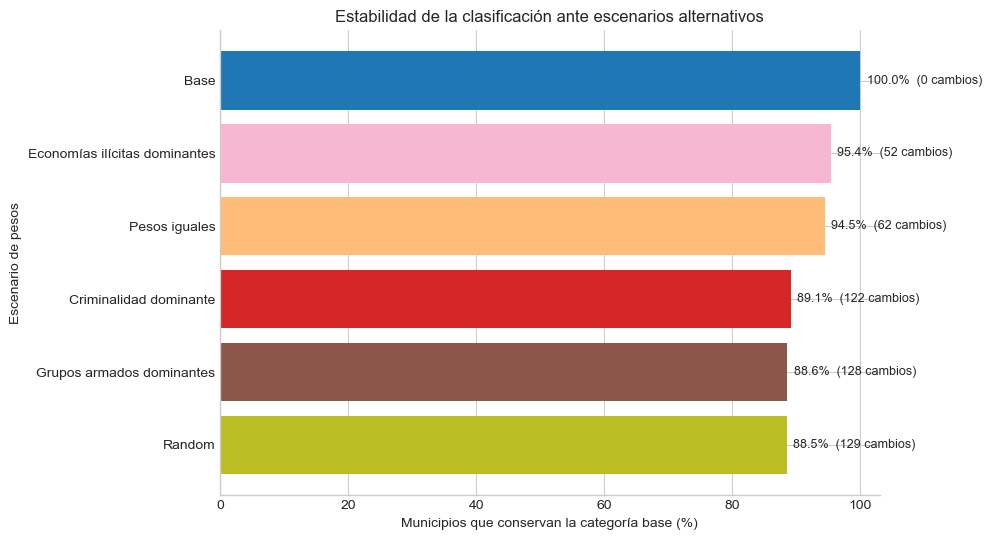

In [13]:
# CELDA 11 — Gráfica 1: coincidencia de categorías bajo escenarios determinísticos.
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
datos_g1 = resumen_escenarios.sort_values('coincidencia_categoria_pct')
# La paleta se genera dinámicamente para admitir cualquier cantidad de escenarios.
mapa_colores = dict(zip(resumen_escenarios['escenario'], plt.cm.tab20(np.linspace(0, 1, len(resumen_escenarios), endpoint=False))))
fig, ax = plt.subplots(figsize=(10, max(5.5, 0.75 * len(datos_g1))))
barras = ax.barh(datos_g1['escenario'], datos_g1['coincidencia_categoria_pct'], color=[mapa_colores[x] for x in datos_g1['escenario']])
ax.set_xlim(0, 103)
ax.set_xlabel('Municipios que conservan la categoría base (%)')
ax.set_ylabel('Escenario de pesos')
ax.set_title('Estabilidad de la clasificación ante escenarios alternativos')
for barra, porcentaje, cambios in zip(barras, datos_g1['coincidencia_categoria_pct'], datos_g1['cambian_de_categoria']):
    ax.text(porcentaje + 1, barra.get_y() + barra.get_height()/2, f'{porcentaje:.1f}%  ({int(cambios)} cambios)', va='center', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
archivo_g1 = OUTPUT_DIR / 'sensibilidad_01_escenarios.png'
fig.savefig(archivo_g1, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


**Qué intenta explicar la gráfica 1.** Mide cuántos municipios conservan su categoría cuando se reemplazan los pesos base por alternativas interpretables. Una barra cercana al 100% indica que la clasificación depende poco de ese cambio. El escenario más exigente es el de grupos armados dominantes: aun allí permanece igual el 88,6% y cambian 128 de 1.122 municipios.

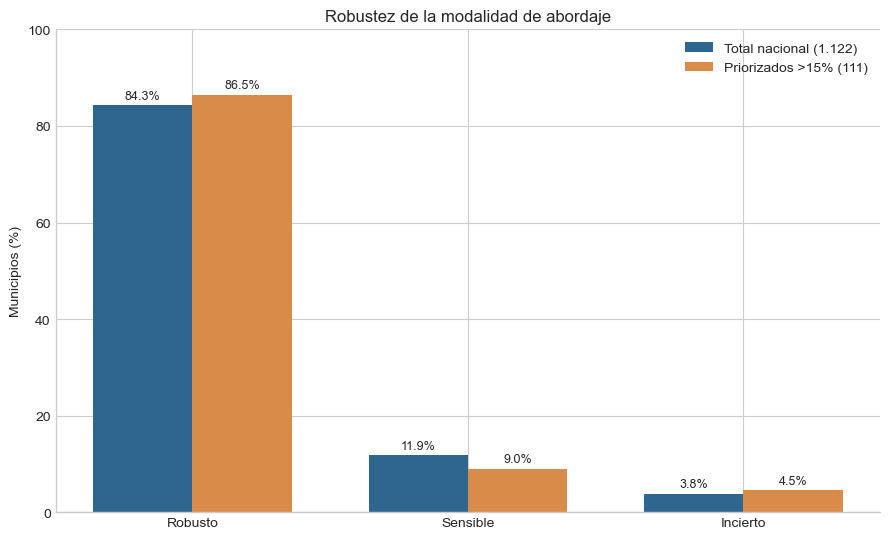

In [14]:
# CELDA 12 — Gráfica 2: robustez global frente a robustez de los 111 municipios priorizados.
orden_robustez = ['Robusto', 'Sensible', 'Incierto']
total_pct = estabilidad_municipal['robustez_clasificacion'].value_counts(normalize=True).reindex(orden_robustez).fillna(0) * 100
priorizados_sens = estabilidad_municipal[estabilidad_municipal['universo_111_densidad_gt15'].eq('SI')]
priorizados_pct = priorizados_sens['robustez_clasificacion'].value_counts(normalize=True).reindex(orden_robustez).fillna(0) * 100
x = np.arange(len(orden_robustez)); ancho = 0.36
fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x - ancho/2, total_pct, ancho, label='Total nacional (1.122)', color='#2F6690')
b2 = ax.bar(x + ancho/2, priorizados_pct, ancho, label='Priorizados >15% (111)', color='#D98C4A')
ax.set_xticks(x, orden_robustez)
ax.set_ylim(0, 100)
ax.set_ylabel('Municipios (%)')
ax.set_title('Robustez de la modalidad de abordaje')
ax.legend(frameon=False)
for barras in [b1, b2]:
    for barra in barras:
        ax.text(barra.get_x()+barra.get_width()/2, barra.get_height()+1.3, f'{barra.get_height():.1f}%', ha='center', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
archivo_g2 = OUTPUT_DIR / 'sensibilidad_02_robustez.png'
fig.savefig(archivo_g2, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


**Qué intenta explicar la gráfica 2.** Compara la estabilidad nacional con la de los 111 municipios seleccionados por disponibilidad. Robusto significa que el municipio conserva su categoría base en al menos 90% de las simulaciones; Sensible, entre 60% y 90%; e Incierto, menos de 60%. Entre los priorizados, 96 son robustos, 10 sensibles y 5 inciertos.

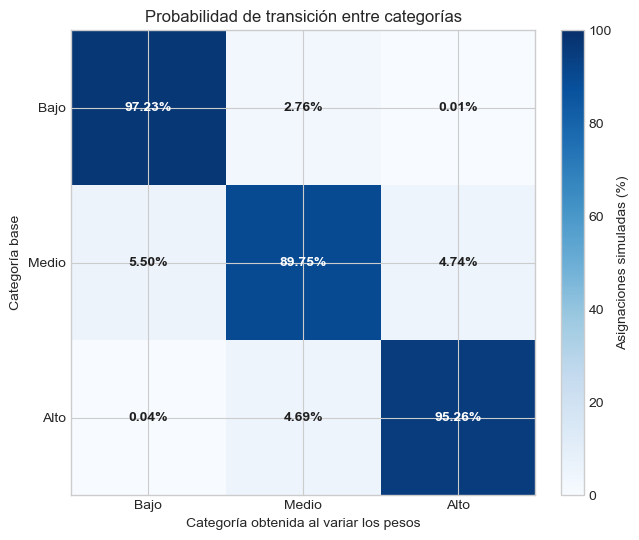

In [15]:
# CELDA 13 — Gráfica 3: matriz de transición probabilística entre categorías.
# Normalizar por fila permite leer cada celda como la proporción de simulaciones que termina en otra categoría.
matriz_pct = matriz_transicion.div(matriz_transicion.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(7, 5.5))
imagen = ax.imshow(matriz_pct.to_numpy(), cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(3), ETIQUETA_RIESGO)
ax.set_yticks(range(3), ETIQUETA_RIESGO)
ax.set_xlabel('Categoría obtenida al variar los pesos')
ax.set_ylabel('Categoría base')
ax.set_title('Probabilidad de transición entre categorías')
for i in range(3):
    for j in range(3):
        valor = matriz_pct.iloc[i, j]
        ax.text(j, i, f'{valor:.2f}%', ha='center', va='center', color='white' if valor > 50 else '#1f1f1f', fontweight='bold')
barra_color = fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
barra_color.set_label('Asignaciones simuladas (%)')
fig.tight_layout()
archivo_g3 = OUTPUT_DIR / 'sensibilidad_03_transiciones.png'
fig.savefig(archivo_g3, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


**Qué intenta explicar la gráfica 3.** La diagonal representa permanencia en la categoría original y los valores fuera de ella representan cambios. Bajo permanece Bajo en 97,23% de las asignaciones; Medio permanece Medio en 89,75%; y Alto permanece Alto en 95,26%. La categoría Medio es la más sensible, principalmente por municipios cercanos a P50 o P75.

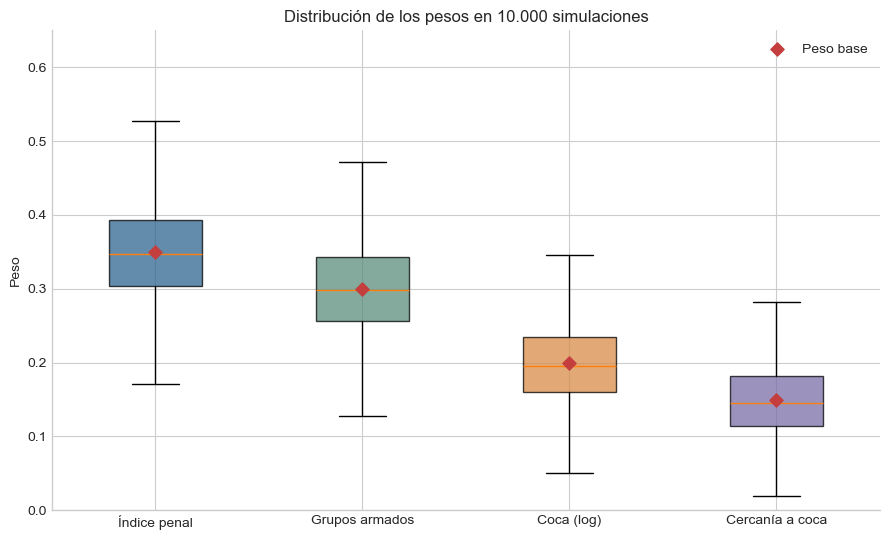

In [16]:
# CELDA 14 — Gráfica 4: rango de pesos explorado por las simulaciones.
# El punto rojo marca el peso base y las cajas muestran la variación generada por Dirichlet.
fig, ax = plt.subplots(figsize=(9, 5.5))
cajas = ax.boxplot([pesos_simulados[:, i] for i in range(4)], tick_labels=NOMBRES_COMPONENTES, patch_artist=True, showfliers=False)
for caja, color in zip(cajas['boxes'], ['#2F6690', '#5B8E7D', '#D98C4A', '#7A6FA8']):
    caja.set_facecolor(color); caja.set_alpha(0.75)
ax.scatter(np.arange(1, 5), PESOS_BASE, color='#C43E3E', marker='D', s=45, label='Peso base', zorder=3)
ax.set_ylim(0, 0.65)
ax.set_ylabel('Peso')
ax.set_title('Distribución de los pesos en 10.000 simulaciones')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
archivo_g4 = OUTPUT_DIR / 'sensibilidad_04_distribucion_pesos.png'
fig.savefig(archivo_g4, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


**Qué intenta explicar la gráfica 4.** Documenta qué tan amplia fue la perturbación de los pesos. El 95% central exploró aproximadamente 0,227–0,488 para el índice penal, 0,186–0,431 para grupos armados, 0,105–0,317 para coca y 0,067–0,260 para cercanía. Esto demuestra que la prueba no se limitó a cambios mínimos, aunque la concentración 50 sigue siendo una decisión analítica que debe declararse.

## Prueba extrema con más iteraciones

Esta sección amplía la sensibilidad a 50.000 iteraciones por diseño. Compara la perturbación moderada actual, una perturbación mucho más amplia alrededor de los pesos base y una distribución uniforme que no privilegia la combinación 35/30/20/15. El cálculo se realiza por lotes para controlar el uso de memoria.

In [17]:
# CELDA 15 — Motor de simulación por lotes para análisis extremos.
# Procesar 50.000 iteraciones de una sola vez requeriría matrices muy grandes; los lotes producen el mismo resultado
# acumulando conteos de categorías, transiciones y pesos sin conservar todos los scores municipales en memoria.
N_SIMULACIONES_EXTREMAS = 50_000
TAMANO_LOTE = 1_000

def simular_por_lotes(nombre, slug, alpha, semilla):
    rng_local = np.random.default_rng(semilla)
    conteos_categoria = np.zeros((len(resultado), 3), dtype=np.int64)
    matriz_local = np.zeros((3, 3), dtype=np.int64)
    pesos_guardados = np.empty((N_SIMULACIONES_EXTREMAS, 4), dtype=float)
    inicio = 0
    while inicio < N_SIMULACIONES_EXTREMAS:
        n_lote = min(TAMANO_LOTE, N_SIMULACIONES_EXTREMAS - inicio)
        pesos_lote = rng_local.dirichlet(alpha, size=n_lote)
        pesos_guardados[inicio:inicio+n_lote] = pesos_lote
        bruto_lote = COMPONENTES_Z @ pesos_lote.T
        score_lote = (bruto_lote - bruto_lote.min(axis=0)) / (bruto_lote.max(axis=0) - bruto_lote.min(axis=0))
        p50_lote, p75_lote = np.quantile(score_lote, [0.50, 0.75], axis=0)
        categorias_lote = np.where(score_lote <= p50_lote, 0, np.where(score_lote <= p75_lote, 1, 2)).astype(np.int8)
        for codigo in range(3):
            conteos_categoria[:, codigo] += (categorias_lote == codigo).sum(axis=1)
        for categoria_base in range(3):
            matriz_local[categoria_base] += np.bincount(categorias_lote[codigo_base == categoria_base].ravel(), minlength=3)
        inicio += n_lote
    probabilidades_locales = conteos_categoria / N_SIMULACIONES_EXTREMAS
    prob_base_local = probabilidades_locales[np.arange(len(resultado)), codigo_base]
    robustez_local = np.select([prob_base_local >= 0.90, prob_base_local >= 0.60], ['Robusto', 'Sensible'], default='Incierto')
    return {
        'nombre': nombre, 'slug': slug, 'alpha': np.asarray(alpha), 'pesos': pesos_guardados,
        'probabilidades': probabilidades_locales, 'probabilidad_base': prob_base_local,
        'robustez': robustez_local, 'matriz': matriz_local,
    }

disenos_extremos = [
    ('Centrada moderada (k=50)', 'moderada_k50', PESOS_BASE * 50, 951),
    ('Centrada amplia (k=10)', 'amplia_k10', PESOS_BASE * 10, 1951),
    ('Uniforme global (1,1,1,1)', 'uniforme', np.ones(4), 2951),
]
resultados_extremos = {slug: simular_por_lotes(nombre, slug, alpha, semilla) for nombre, slug, alpha, semilla in disenos_extremos}
print(f'Se ejecutaron {N_SIMULACIONES_EXTREMAS:,} iteraciones para cada uno de los {len(disenos_extremos)} diseños.')


Se ejecutaron 50,000 iteraciones para cada uno de los 3 diseños.


In [18]:
# CELDA 16 — Resumen y auditoría de los diseños extremos.
filas_extremas = []
detalle_extremo = resultado[['id_unificado', 'COD_MPIO_DIVIPOLA', 'nombre_departamento', 'nombre_municipio', 'universo_111_densidad_gt15', 'riesgo_categoria']].copy()
for nombre, slug, alpha, semilla in disenos_extremos:
    r = resultados_extremos[slug]
    conteos = pd.Series(r['robustez']).value_counts().reindex(['Robusto', 'Sensible', 'Incierto']).fillna(0)
    pesos_maximos = r['pesos'].max(axis=1)
    filas_extremas.append({
        'diseño': nombre,
        'iteraciones': N_SIMULACIONES_EXTREMAS,
        'coincidencia_media_categoria_base_pct': r['probabilidad_base'].mean() * 100,
        'robustos_pct': conteos['Robusto'] / len(resultado) * 100,
        'sensibles_pct': conteos['Sensible'] / len(resultado) * 100,
        'inciertos_pct': conteos['Incierto'] / len(resultado) * 100,
        'peso_maximo_mediano': np.median(pesos_maximos),
        'simulaciones_con_peso_mayor_50_pct': (pesos_maximos > 0.50).mean() * 100,
    })
    detalle_extremo[f'probabilidad_base_{slug}'] = r['probabilidad_base']
    detalle_extremo[f'robustez_{slug}'] = r['robustez']
    assert np.allclose(r['pesos'].sum(axis=1), 1)
    assert int(r['matriz'].sum()) == len(resultado) * N_SIMULACIONES_EXTREMAS

resumen_extremo = pd.DataFrame(filas_extremas).round(4)
display(resumen_extremo)
archivo_resumen_extremo = OUTPUT_DIR / 'VENTO_sensibilidad_extrema_50000_resumen.csv'
archivo_detalle_extremo = OUTPUT_DIR / 'VENTO_sensibilidad_extrema_50000_municipios.csv'
resumen_extremo.to_csv(archivo_resumen_extremo, index=False, encoding='utf-8-sig')
detalle_extremo.round(6).to_csv(archivo_detalle_extremo, index=False, encoding='utf-8-sig')


,diseño,iteraciones,coincidencia_media_categoria_base_pct,robustos_pct,sensibles_pct,inciertos_pct,peso_maximo_mediano,simulaciones_con_peso_mayor_50_pct
0,Centrada moderada (k=50),50000,94.8282,84.2246,11.8538,3.9216,0.3706,1.708
1,Centrada amplia (k=10),50000,89.6516,69.1622,22.1034,8.7344,0.4364,27.250
2,"Uniforme global (1,1,1,1)",50000,85.5546,57.6649,30.0357,12.2995,0.4994,49.838


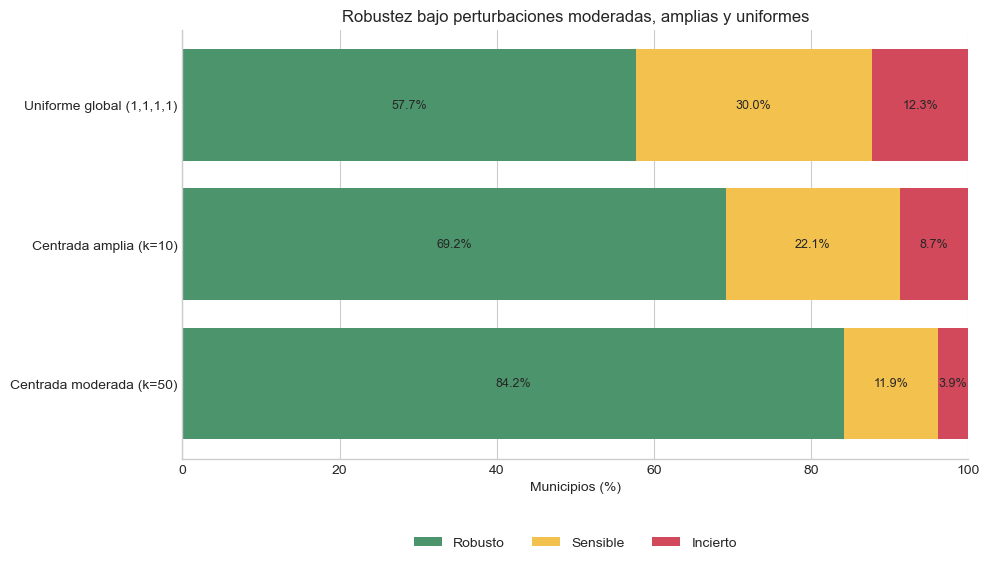

In [19]:
# CELDA 17 — Gráfica comparativa de robustez bajo diseños cada vez más extremos.
orden = ['robustos_pct', 'sensibles_pct', 'inciertos_pct']
etiquetas = ['Robusto', 'Sensible', 'Incierto']
colores = ['#4C956C', '#F2C14E', '#D1495B']
fig, ax = plt.subplots(figsize=(10, 5.8))
izquierda = np.zeros(len(resumen_extremo))
for columna, etiqueta, color in zip(orden, etiquetas, colores):
    valores = resumen_extremo[columna].to_numpy()
    barras = ax.barh(resumen_extremo['diseño'], valores, left=izquierda, label=etiqueta, color=color)
    for i, (valor, base_izq) in enumerate(zip(valores, izquierda)):
        if valor >= 3:
            ax.text(base_izq + valor/2, i, f'{valor:.1f}%', ha='center', va='center', fontsize=9)
    izquierda += valores
ax.set_xlim(0, 100)
ax.set_xlabel('Municipios (%)')
ax.set_title('Robustez bajo perturbaciones moderadas, amplias y uniformes')
ax.legend(frameon=False, ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.24))
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
archivo_g5 = OUTPUT_DIR / 'sensibilidad_05_comparacion_extrema.png'
fig.savefig(archivo_g5, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


**Qué intenta explicar esta gráfica.** Si la proporción robusta cae al ampliar o eliminar la preferencia por los pesos base, significa que parte de la estabilidad inicial dependía de concentrar las simulaciones alrededor de 35/30/20/15. La Dirichlet uniforme es la prueba más severa porque cualquier combinación de pesos que sume 100% tiene la misma densidad de probabilidad.

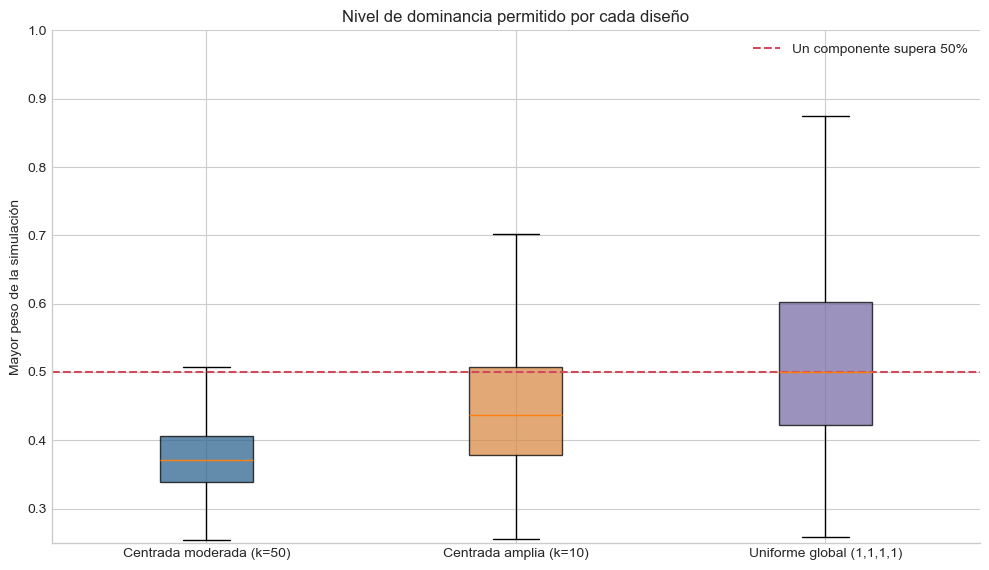

In [20]:
# CELDA 18 — Gráfica del peso dominante para demostrar qué tan extremos fueron los diseños.
fig, ax = plt.subplots(figsize=(10, 5.8))
datos_maximos = [resultados_extremos[slug]['pesos'].max(axis=1) for _, slug, _, _ in disenos_extremos]
cajas = ax.boxplot(datos_maximos, tick_labels=[nombre for nombre, _, _, _ in disenos_extremos], patch_artist=True, showfliers=False)
for caja, color in zip(cajas['boxes'], ['#2F6690', '#D98C4A', '#7A6FA8']):
    caja.set_facecolor(color); caja.set_alpha(0.75)
ax.axhline(0.50, color='#D1495B', linestyle='--', linewidth=1.5, label='Un componente supera 50%')
ax.set_ylabel('Mayor peso de la simulación')
ax.set_ylim(0.25, 1.0)
ax.set_title('Nivel de dominancia permitido por cada diseño')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
archivo_g6 = OUTPUT_DIR / 'sensibilidad_06_dominancia_pesos.png'
fig.savefig(archivo_g6, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


**Qué intenta explicar esta gráfica.** Para cada simulación toma el mayor de los cuatro pesos. Una caja más alta indica que el diseño permite que una sola variable domine el risk score. Esto confirma visualmente que concentración 10 y, especialmente, Dirichlet uniforme son pruebas más extremas que concentración 50.